In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import font_manager

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']   # 指定中文字体
plt.rcParams['axes.unicode_minus'] = False              # 解决负号显示问题

In [2]:

data = {
    "month": ["1月","2月","3月","4月","5月","6月","7月","8月","9月","10月","11月","12月"],
    "PV": [52285,60178,83608,94602,88066,78431,95484,105585,68773,56048,49474,49965],
    "Load": [99252,125606,124538,129517,116651,120566,124086,132005,131141,108861,98649,83972],
    "Curtail": [24454,23088,40336,45751,42382,33912,44146,50418,27116,23514,23358,26360]
}

df = pd.DataFrame(data)

In [29]:
# 2. 自定义 IRR（避免 np.irr NaN）
# ================================
def npv(rate, cashflows):
    return sum(cf / (1 + rate) ** t for t, cf in enumerate(cashflows))

def irr_bisection(cashflows, low=-0.9, high=10, tol=1e-6):
    # 无正现金流 → IRR不存在
    if all(cf <= 0 for cf in cashflows[1:]):
        return None

    f_low = npv(low, cashflows)
    f_high = npv(high, cashflows)

    if f_low * f_high > 0:
        return None  # 无变号 → 无 IRR

    for _ in range(200):
        mid = (low + high) / 2
        f_mid = npv(mid, cashflows)

        if abs(f_mid) < tol:
            return mid

        if f_low * f_mid < 0:
            high = mid
            f_high = f_mid
        else:
            low = mid
            f_low = f_mid
    return mid


# ================================
# 3. 三段式收益模型（按优先级）
# ================================
def simulate_annual_gain(storage_MWh, buy_price, df):
    export_price = 0.285
    annual_energy = 0
    annual_gain = 0

    for _, row in df.iterrows():
        PV = row["PV"]
        Load = row["Load"]
        Curtail = row["Curtail"]

        # ① PV 自用
        PV_self = min(PV, Load)
        Gain1 = PV_self * 1000 * buy_price
        load_after_PV = max(Load - PV_self, 0)

        # ② 储能平移弃电
        storage_used = min(storage_MWh, Curtail, load_after_PV)
        Gain3 = storage_used * 1000 * buy_price

        # ③ PV 上网 ≤20%
        PV_left = PV - PV_self - storage_used
        PV_export = min(max(PV_left, 0), PV * 0.20)
        Gain2 = PV_export * 1000 * export_price

        annual_gain += (Gain1 + Gain2 + Gain3)
        annual_energy += (PV_self + storage_used + PV_export)  # 整体发电计 O&M

    return annual_gain, annual_energy


# ================================
# 4. IRR 计算（包含 PV CAPEX）
# ================================
def calculate_IRR(df, storage_range, buy_price,
                  PV_CAPEX=2300000000,           # 光伏 23 亿
                  storage_cost_per_kWh=800,      # 800 元/kWh
                  life_years=12,
                  platform_fee=9000000,          # 平台费用900万/年
                  o_and_m_price=0.04):           # O&M 单价 0.04 元/kWh

    rows = []

    for cap in storage_range:

        # 年收益（元） + 年发电量（MWh）
        annual_gain, annual_energy = simulate_annual_gain(cap, buy_price, df)

        # 年 O&M
        OandM = annual_energy * 1000 * o_and_m_price

        # 总架构的年度净现金流
        annual_CF = annual_gain - OandM - platform_fee

        # 储能 CAPEX
        Storage_CAPEX = cap * 1000 * storage_cost_per_kWh

        # 总 CAPEX = 光伏 + 储能
        Total_CAPEX = PV_CAPEX + Storage_CAPEX

        # 现金流序列（20 年寿命）
        cashflows = [-Total_CAPEX] + [annual_CF] * life_years

        IRR = irr_bisection(cashflows)

        rows.append([cap, annual_gain, annual_CF, Total_CAPEX, IRR])

    return pd.DataFrame(rows, columns=[
        "Storage_MWh", "AnnualRevenue_Yuan", "AnnualCF_Yuan",
        "TotalCAPEX_Yuan", "IRR"
    ])

In [25]:
# 5. 参数区 & 运行
# ================================
cap_range = np.arange(400, 981, 50)        # 储能规模
price_range = np.arange(0.30, 0.501, 0.02) # 购电价



In [26]:
# ===========================
#  运行
# ===========================
result = scan_irrs(
    df,
    cap_range,
    price_range,
    storage_cost_per_kWh=800,
    life_years=25,
    o_and_m_rate=0.02
)
print(result)
# 保存 Excel
result.to_excel("storage_IRR_result.xlsx", index=False)
print("✔ 表格已生成：storage_IRR_result.xlsx")

     Storage_MWh  BuyPrice  AnnualGain_Yuan  Annual_O&M_Yuan  \
0            400       0.3      266189700.0       52400000.0   
1            450       0.3      266369700.0       53200000.0   
2            500       0.3      266549700.0       54000000.0   
3            550       0.3      266729700.0       54800000.0   
4            600       0.3      266909700.0       55600000.0   
..           ...       ...              ...              ...   
127          750       0.5      445749500.0       58000000.0   
128          800       0.5      446049500.0       58800000.0   
129          850       0.5      446349500.0       59600000.0   
130          900       0.5      446649500.0       60400000.0   
131          950       0.5      446949500.0       61200000.0   

     Total_CAPEX_Yuan       IRR  
0          2620000000  0.064495  
1          2660000000  0.062559  
2          2700000000  0.060666  
3          2740000000  0.058813  
4          2780000000  0.057000  
..                ...      

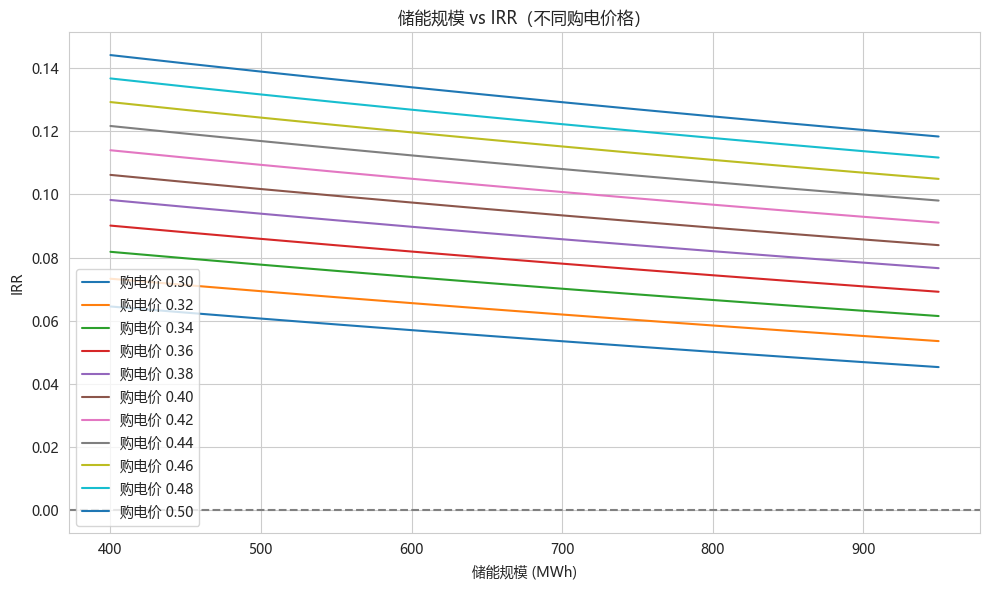

✔ IRR 曲线图已生成


In [27]:


# ===========================
# 绘制 IRR 曲线图
# ===========================

plt.figure(figsize=(10,6))

for price in price_range:
    subset = result[result["BuyPrice"] == price]
    plt.plot(subset["Storage_MWh"], subset["IRR"], label=f"购电价 {price:.2f}")

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("储能规模 (MWh)")
plt.ylabel("IRR")
plt.title("储能规模 vs IRR（不同购电价格）")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("✔ IRR 曲线图已生成")

✔ 已生成：PV_Storage_IRR_scan.xlsx


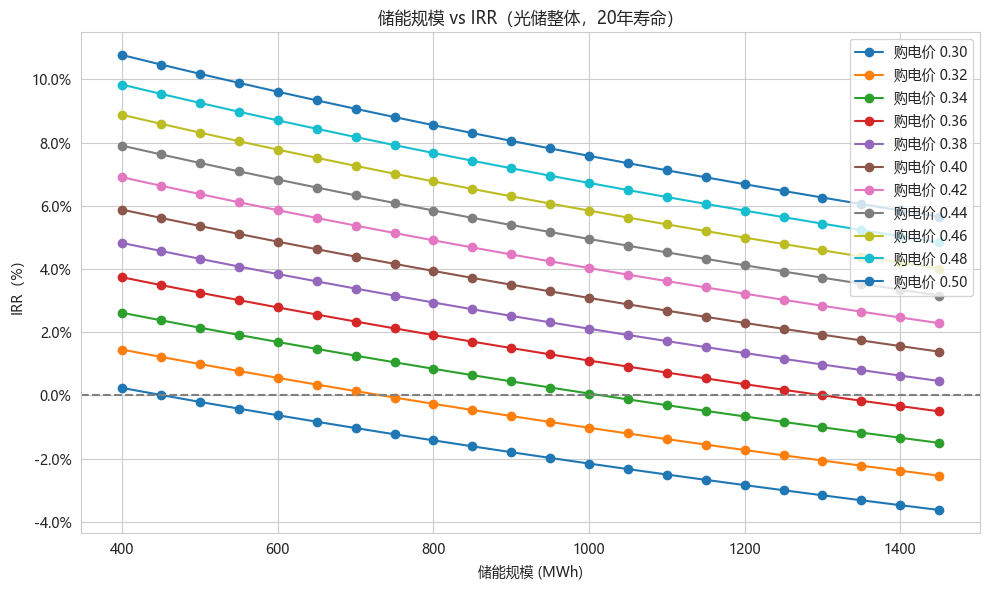

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 0. 图表中文设置（防乱码）
# ================================
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ================================
# 1. 月度数据（单位：MWh）
# ================================
data = {
    "month": ["1月","2月","3月","4月","5月","6月","7月","8月","9月","10月","11月","12月"],
    "PV":      [52285,60178,83608,94602,88066,78431,95484,105585,68773,56048,49474,49965],
    "Load":    [99252,125606,124538,129517,116651,120566,124086,132005,131141,108861,98649,83972],
    "Curtail": [24454,23088,40336,45751,42382,33912,44146,50418,27116,23514,23358,26360]
}
df = pd.DataFrame(data)

# ================================
# 2. 自定义 NPV & IRR（二分法）
# ================================
def npv(rate, cashflows):
    return sum(cf / (1 + rate) ** t for t, cf in enumerate(cashflows))

def irr_bisection(cashflows, low=-0.9, high=10, tol=1e-6, max_iter=200):
    # 如果后续现金流全 <= 0，则不存在 IRR
    if all(cf <= 0 for cf in cashflows[1:]):
        return None

    f_low = npv(low, cashflows)
    f_high = npv(high, cashflows)

    # 无变号 => 区间内无 IRR
    if f_low * f_high > 0:
        return None

    for _ in range(max_iter):
        mid = (low + high) / 2
        f_mid = npv(mid, cashflows)

        if abs(f_mid) < tol:
            return mid

        if f_low * f_mid < 0:
            high = mid
            f_high = f_mid
        else:
            low = mid
            f_low = f_mid

    return mid

# ================================
# 3. 三段式收益模型（优先级：PV自用→储能平移→上网≤20%）
# ================================
def simulate_annual_gain(storage_MWh, buy_price, df):
    """
    storage_MWh : 储能容量 (MWh)
    buy_price   : 购电/自用电价 (元/kWh)
    返回：
        annual_gain  : 年度总收益（元）
        annual_energy: 年度总“售出/使用”电量（MWh，用于算 O&M）
    """
    export_price = 0.285  # 上网电价，固定不变
    annual_gain = 0.0
    annual_energy = 0.0

    for _, row in df.iterrows():
        PV = row["PV"]          # MWh
        Load = row["Load"]      # MWh
        Curtail = row["Curtail"]# MWh

        # ① PV 直接抵消负荷
        PV_self = min(PV, Load)
        Gain1 = PV_self * 1000 * buy_price
        load_after_PV = max(Load - PV_self, 0)

        # ② 储能平移弃电补负荷
        storage_used = min(storage_MWh, Curtail, load_after_PV)
        Gain3 = storage_used * 1000 * buy_price

        # ③ 剩余 PV 上网（≤20%）
        PV_left = PV - PV_self - storage_used
        PV_export = min(max(PV_left, 0), PV * 0.20)
        Gain2 = PV_export * 1000 * export_price

        # 收益累计
        annual_gain += (Gain1 + Gain2 + Gain3)
        # 所有“真正卖出去/用掉”的电量，用来算 O&M
        annual_energy += (PV_self + storage_used + PV_export)

    return annual_gain, annual_energy

# ================================
# 4. 光储整体 IRR 扫描（轮巡：储能规模 × 购电电价）
# ================================
def scan_IRR_pv_storage(
    df,
    storage_range,
    buy_price_range,
    PV_CAPEX=2300000000,       # PV投资 23亿
    storage_cost_per_kWh=800,  # 储能 800 元/kWh
    life_years=20,
    platform_fee=9_000_000,    # 平台费 900 万/年
    o_and_m_price=0.04         # O&M 0.04 元/kWh
):
    rows = []

    for buy_price in buy_price_range:
        for cap in storage_range:

            # 计算收益和发电量
            annual_gain, annual_energy = simulate_annual_gain(cap, buy_price, df)

            # 年度 O&M 成本（按电量）
            OandM = annual_energy * 1000 * o_and_m_price

            # 年度净现金流（收益-运维-平台费）
            annual_CF = annual_gain - OandM - platform_fee

            # 储能 CAPEX
            Storage_CAPEX = cap * 1000 * storage_cost_per_kWh

            # 总 CAPEX：光伏 + 储能
            Total_CAPEX = PV_CAPEX + Storage_CAPEX

            # 现金流：第0年投资，后续life_years年每年 same CF
            cashflows = [-Total_CAPEX] + [annual_CF] * life_years

            IRR = irr_bisection(cashflows)

            rows.append([
                cap,
                buy_price,
                annual_gain,
                annual_energy,
                OandM,
                annual_CF,
                Total_CAPEX,
                IRR * 100 if IRR is not None else None
            ])

    return pd.DataFrame(rows, columns=[
        "Storage_MWh",
        "BuyPrice_YuanPerKWh",
        "AnnualRevenue_Yuan",
        "AnnualEnergy_MWh",
        "Annual_O&M_Yuan",
        "AnnualCF_Yuan",
        "TotalCAPEX_Yuan",
        "IRR_percent"
    ])

# ================================
# 5. 配置轮巡参数 & 运行
# ================================
# 储能容量：例如 100~1500 MWh，步长100
storage_range = np.arange(400, 1500, 50)

# PV 抵消负荷电价（购电价）：比如 0.30~0.50，步长 0.02
buy_price_range = np.arange(0.30, 0.501, 0.02)

result = scan_IRR_pv_storage(
    df,
    storage_range,
    buy_price_range,
    PV_CAPEX=2_300_000_000,
    storage_cost_per_kWh=800,
    life_years=12,
    platform_fee=9_000_000,
    o_and_m_price=0.04
)

# 保存结果表格
result.to_excel("PV_Storage_IRR_scan.xlsx", index=False)
print("✔ 已生成：PV_Storage_IRR_scan.xlsx")

# ================================
# 6. 画图：x=储能规模，y=IRR，曲线=不同购电价
# ================================
plt.figure(figsize=(10, 6))

for buy_price in buy_price_range:
    sub = result[result["BuyPrice_YuanPerKWh"] == buy_price]
    plt.plot(sub["Storage_MWh"], sub["IRR_percent"], marker='o',
             label=f"购电价 {buy_price:.2f}")

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("储能规模 (MWh)")
plt.ylabel("IRR（%）")
plt.title("储能规模 vs IRR（光储整体，20年寿命）")
plt.grid(True)
plt.legend(loc='upper right')

# y 轴格式化为百分比
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.1f}%")

plt.tight_layout()
plt.show()


In [41]:
# ================================
# 7. 计算每变化 50 MWh 的 IRR 变化规律（ΔIRR）
# ================================
delta_rows = []

for buy_price in buy_price_range:
    sub = result[result["BuyPrice_YuanPerKWh"] == buy_price].sort_values("Storage_MWh")

    # 遍历相邻容量（差值 = 50MWh）
    for i in range(len(sub) - 1):
        s1 = sub.iloc[i]
        s2 = sub.iloc[i + 1]

        Delta_IRR_percent = None
        if s1["IRR"] is not None and s2["IRR"] is not None:
            Delta_IRR_percent = (s2["IRR"] - s1["IRR"]) * 100

        delta_rows.append([
            buy_price,
            s1["Storage_MWh"],
            s2["Storage_MWh"],
            Delta_IRR_percent
        ])

df_delta = pd.DataFrame(delta_rows, columns=[
    "BuyPrice",
    "Storage_MWh_From",
    "Storage_MWh_To",
    "Delta_IRR"
])

df_delta.to_excel("Storage_IRR_Delta_50MWh.xlsx", index=False)
print("✔ ΔIRR 文件已生成：Storage_IRR_Delta_50MWh.xlsx")

# ================================
# 8. 绘制 ΔIRR 变化规律图
# ================================
plt.figure(figsize=(10, 6))

for buy_price in buy_price_range:
    sub = df_delta[df_delta["BuyPrice"] == buy_price]
    plt.plot(sub["Storage_MWh_From"], sub["Delta_IRR_percent"], marker='o',
             label=f"购电价 {buy_price:.2f}")

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("储能规模 (MWh)")
plt.ylabel("ΔIRR（每增加50 MWh 的 IRR 变化）")
plt.title("储能规模变化 50 MWh 时的 IRR 变化规律")
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

KeyError: 'IRR'